# Pertemuan 13 — Pengantar Topik Lanjutan: Deep Learning & NLP Dasar

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 19 Juli 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 13 menjadi jembatan menuju dua pilar besar AI modern, dan terdiri dari **dua bagian**:

1. **Deep Learning — Artificial Neural Network (ANN)** — membangun neural network sederhana dengan **Keras/TensorFlow** (`Sequential`, `Dense`, activation **ReLU** & **Sigmoid**) untuk kasus **klasifikasi non-linear** (dataset `make_moons`, dua kelas berbentuk bulan sabit yang mustahil dipisahkan garis lurus), lalu mengamati proses belajarnya lewat **kurva akurasi training vs validasi**.
2. **NLP Dasar — Analisis Sentimen dengan TF-IDF** — mengubah **40 ulasan produk berbahasa Indonesia** menjadi representasi numerik dengan **`TfidfVectorizer`**, melatih **Logistic Regression** untuk memprediksi sentimen **positif/negatif**, lalu mengujinya pada kalimat baru.

Berbeda dari pertemuan sebelumnya yang penuh formula, fokus pertemuan ini adalah **intuisi konseptual**: bagaimana neuron buatan belajar (forward pass → hitung error → backpropagation → update weight), dan bagaimana teks diubah menjadi angka sebelum bisa diproses model.

## Langkah 0 — Setup Library

Import semua library yang dibutuhkan. **TensorFlow/Keras** dipakai untuk membangun neural network (di Google Colab sudah terpasang secara default), sedangkan **scikit-learn** dipakai untuk dataset sintetis (`make_moons`), split data, **`TfidfVectorizer`**, dan **`LogisticRegression`**. Seed diset agar hasil **reprodusibel**.

In [13]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'    # sembunyikan log info/warning internal TensorFlow
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Set seed agar hasil training reprodusibel
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print('TensorFlow versi :', tf.__version__)
print('Setup selesai — semua library siap dipakai.')

TensorFlow versi : 2.20.0
Setup selesai — semua library siap dipakai.


---
# BAGIAN 1 — Neural Network untuk Klasifikasi Non-Linear

## Langkah 1 — Generate & Eksplorasi Dataset Non-Linear

Kita bangkitkan dataset **`make_moons`**: **300 titik data, 2 kelas** berbentuk **bulan sabit** yang saling bertautan. Dataset ini adalah kasus klasik untuk menunjukkan **keterbatasan model linear** — tidak ada satu garis lurus pun yang mampu memisahkan kedua kelas, sehingga dibutuhkan model yang mampu belajar **pola non-linear** (di sinilah peran **activation function** pada neural network).

Bentuk X : (300, 2)
Bentuk y : (300,)
Distribusi kelas: [150 150]


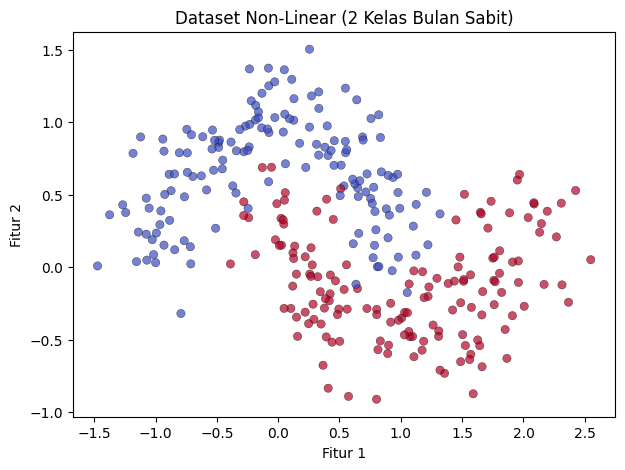

In [14]:
# Langkah 1: Bangkitkan dataset non-linear (2 kelas berbentuk bulan sabit)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

print('Bentuk X :', X.shape)   # 300 titik, 2 fitur (koordinat x1, x2)
print('Bentuk y :', y.shape)   # 300 label (0 atau 1)
print('Distribusi kelas:', np.bincount(y))

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1'); plt.ylabel('Fitur 2')
plt.show()

**Bacaan EDA:**
- Kedua kelas (merah & biru) berbentuk **bulan sabit yang saling melengkung dan bertautan** — mustahil dipisahkan dengan **satu garis lurus** (decision boundary linear).
- Distribusi kelas **seimbang** (150 : 150), sehingga **accuracy** aman dipakai sebagai metrik utama (tidak ada *accuracy paradox* seperti kasus imbalanced di Pertemuan 10).
- Parameter `noise=0.2` menambahkan sebaran acak sehingga ada sedikit **tumpang tindih** di daerah pertemuan kedua sabit — realistis, dan berarti akurasi 100% hampir mustahil (dan justru patut dicurigai overfitting).
- Inilah alasan kita butuh **neural network dengan activation function non-linear**: tanpa aktivasi, network bertingkat pun secara matematis tetap setara dengan satu regresi linear biasa.

## Langkah 2 — Bangun & Latih Neural Network Sederhana

Arsitektur mengikuti modul: **2 hidden layer** dengan aktivasi **ReLU** dan **1 output neuron** dengan aktivasi **Sigmoid**:

| Layer | Neuron | Activation | Peran |
|---|---|---|---|
| Hidden 1 | 16 | **ReLU** — `max(0, x)` | Menangkap pola non-linear, cepat dihitung |
| Hidden 2 | 8 | **ReLU** | Memperhalus representasi fitur |
| Output | 1 | **Sigmoid** — output 0–1 | Probabilitas kelas untuk **klasifikasi biner** |

Kompilasi memakai optimizer **`adam`** dan loss **`binary_crossentropy`** (standar klasifikasi biner). Training dijalankan **30 epoch** — satu **epoch** = satu putaran penuh **forward pass + backpropagation** untuk seluruh data training. `validation_split=0.2` menyisihkan 20% data latih sebagai data validasi untuk memantau overfitting.

In [15]:
# Langkah 2a: Split data latih & uji (80 : 20)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Data latih:', X_tr.shape[0], 'titik | Data uji:', X_te.shape[0], 'titik')

# Langkah 2b: Bangun arsitektur neural network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Data latih: 240 titik | Data uji: 60 titik


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Langkah 2c: Latih model — Keras otomatis menjalankan forward pass & backpropagation
history = model.fit(X_tr, y_tr, epochs=30,
                    validation_split=0.2, verbose=0)

print('Training selesai:', len(history.history['accuracy']), 'epoch')
print(f"Akurasi training  (epoch terakhir): {history.history['accuracy'][-1]:.3f}")
print(f"Akurasi validasi  (epoch terakhir): {history.history['val_accuracy'][-1]:.3f}")

Training selesai: 30 epoch
Akurasi training  (epoch terakhir): 0.849
Akurasi validasi  (epoch terakhir): 0.875


**Bacaan arsitektur & training:**
- `model.summary()` menunjukkan jumlah **parameter** yang dipelajari: hidden 1 = (2×16)+16 = **48**, hidden 2 = (16×8)+8 = **136**, output = (8×1)+1 = **9** → total **193 parameter** (weight + bias). Semua nilai inilah yang di-*update* sedikit demi sedikit oleh backpropagation di setiap epoch.
- Alur belajarnya persis 4 tahap di modul: **Forward Pass** (data mengalir input → output menghasilkan prediksi) → **Hitung Error** (prediksi vs jawaban benar via `binary_crossentropy`) → **Backpropagation** (error dialirkan **mundur** dari output ke input untuk mengetahui kontribusi tiap weight terhadap kesalahan) → **Update Weight** (optimizer `adam` memperbaiki weight), diulang **30 epoch**.
- `verbose=0` hanya menyembunyikan log per-epoch agar notebook rapi — proses trainingnya tetap berjalan penuh.

## Langkah 3 — Evaluasi & Visualisasi Kurva Belajar

Model dievaluasi pada **data uji** (60 titik yang tidak pernah dilihat saat training), lalu kurva **akurasi training vs validasi** diplot untuk membaca proses belajarnya: apakah kedua kurva **saling mendekat** (belajar sehat) atau **saling menjauh** (indikasi overfitting).

Akurasi pada data uji : 0.900
Loss pada data uji    : 0.328


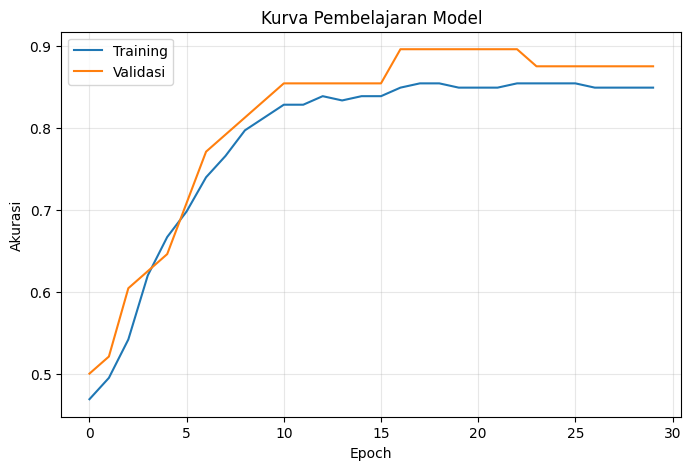

In [17]:
# Langkah 3a: Evaluasi pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji : {acc:.3f}')
print(f'Loss pada data uji    : {loss:.3f}')

# Langkah 3b: Plot kurva pembelajaran
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.grid(alpha=0.3)
plt.show()

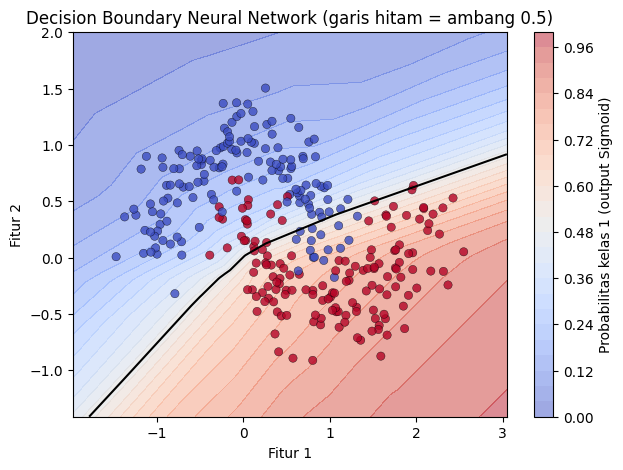

In [6]:
# Langkah 3c (eksplorasi tambahan): Visualisasi decision boundary yang dipelajari model
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 300),
                     np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
proba = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, proba, levels=25, cmap='coolwarm', alpha=0.5)
plt.colorbar(label='Probabilitas kelas 1 (output Sigmoid)')
plt.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', linewidths=0.3, alpha=0.8)
plt.title('Decision Boundary Neural Network (garis hitam = ambang 0.5)')
plt.xlabel('Fitur 1'); plt.ylabel('Fitur 2')
plt.show()

**Interpretasi kurva belajar & decision boundary:**
- **Kurva training dan validasi naik beriringan dan saling mendekat** di epoch-epoch akhir — pola belajar yang **sehat, tidak ada indikasi overfitting** (kurva tidak saling menjauh). Wajar, karena modelnya kecil (193 parameter) relatif terhadap 240 data latih.
- Akurasi data uji **≈ 0.90** — model berhasil memisahkan dua kelas yang **tidak mungkin dipisahkan model linear**. Sisa kesalahan berada di daerah tumpang tindih akibat `noise=0.2`, bukan karena model gagal menangkap polanya.
- Plot decision boundary membuktikannya secara visual: garis batas keputusan (hitam, ambang 0.5) **melengkung mengikuti bentuk bulan sabit** — bukti langsung bahwa kombinasi **ReLU** di hidden layer memberi model kemampuan **non-linear**. Ini persis pesan kunci modul: *tanpa activation function, network bertingkat pun tetap setara satu regresi linear*.
- Kurva masih menanjak perlahan di epoch 30 → menambah epoch (mis. 100) kemungkinan masih menaikkan akurasi sedikit sebelum mendatar (konvergen). Sesuai modul, training dihentikan ketika performa "cukup baik atau tidak lagi meningkat signifikan".

---
# BAGIAN 2 — NLP Dasar: Analisis Sentimen dengan TF-IDF

## Langkah 4 — Siapkan Dataset Ulasan Produk

Kita susun **40 ulasan produk sintetis berbahasa Indonesia** dengan label seimbang: **20 positif (label 1)** dan **20 negatif (label 0)** — meniru ulasan marketplace pada umumnya (kata kunci positif: *bagus, puas, cepat, recommended*; negatif: *jelek, rusak, kecewa, buruk*).

In [7]:
# Langkah 4: Dataset 40 ulasan produk (20 positif + 20 negatif)
ulasan = [
    # ── 20 ulasan POSITIF ──
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, kualitas bagus, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Kualitas bagus, packing rapi dan aman',
    'Penjual ramah, respon cepat, barang original',
    'Produk sesuai deskripsi, sangat memuaskan',
    'Pengiriman cepat, barang mulus tidak ada cacat',
    'Harga murah tapi kualitas bagus, puas banget',
    'Bahan tebal dan nyaman dipakai, sangat puas',
    'Pelayanan memuaskan, barang bagus, pasti beli lagi',
    'Barang datang cepat dan sesuai pesanan, mantap',
    'Produk bagus, berfungsi sempurna, sangat puas',
    'Warna sesuai foto, jahitan rapi, kualitas bagus',
    'Packing aman, pengiriman cepat, barang bagus',
    'Kualitas memuaskan, melebihi ekspektasi saya',
    'Toko amanah, barang original, sangat recommended',
    'Ukuran pas, bahan nyaman, puas sekali',
    'Transaksi mudah, barang bagus, penjual ramah',
    'Sangat recommended, pelayanan cepat dan memuaskan',
    'Produk awet, kualitas bagus, puas belanja di sini',
    # ── 20 ulasan NEGATIF ──
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman lama, packing jelek asal-asalan',
    'Barang cacat dan rusak, penjual susah dihubungi',
    'Warna pudar, jelek, beda jauh dari foto',
    'Bahan tipis dan jelek, sangat kecewa',
    'Baru dipakai sekali langsung rusak, kecewa berat',
    'Ukuran tidak sesuai pesanan, komplain tidak ditanggapi',
    'Barang palsu, tidak original, sangat mengecewakan',
    'Pelayanan buruk, respon lama, tidak sopan',
    'Produk jelek, kualitas rendah, tidak recommended',
    'Jahitan lepas, barang rusak, buang uang saja',
    'Barang datang tidak lengkap, kecewa dengan toko ini',
    'Produk tidak berfungsi, rusak total, kecewa',
    'Refund ditolak padahal barang rusak, pelayanan buruk',
    'Packing jelek, barang penyok dan tergores',
    'Deskripsi menipu, barang aslinya jelek sekali',
    'Menyesal belanja di sini, kualitas buruk',
    'Kualitas sangat jelek, kecewa, tidak akan beli lagi',
]
label = [1]*20 + [0]*20   # 1 = positif, 0 = negatif

print('Jumlah ulasan :', len(ulasan))
print('Positif :', label.count(1), '| Negatif :', label.count(0))
print('\nContoh ulasan positif :', ulasan[0])
print('Contoh ulasan negatif :', ulasan[20])

Jumlah ulasan : 40
Positif : 20 | Negatif : 20

Contoh ulasan positif : Barangnya bagus banget, pengiriman cepat
Contoh ulasan negatif : Kualitas jelek, tidak sesuai deskripsi


## Langkah 5 — Ubah Teks Menjadi Vektor TF-IDF

Model machine learning **hanya bisa memproses angka**, sehingga teks harus melewati **text vectorization**. **TF-IDF** menyempurnakan Bag-of-Words dengan **pembobotan**:

$$TF\text{-}IDF = TF \times IDF$$

| Komponen | Definisi |
|---|---|
| **TF** (Term Frequency) | Jumlah kemunculan kata dalam **satu dokumen** |
| **IDF** (Inverse Document Frequency) | `log(total dokumen / jumlah dokumen yang mengandung kata itu)` |

Efeknya: kata umum yang muncul di banyak dokumen (mis. *dan*, *tidak*, *barang*) diberi **bobot rendah**, sedangkan kata **jarang tapi khas** suatu dokumen diberi **bobot tinggi** — semakin tinggi skor TF-IDF, semakin **mencirikan** kata itu bagi dokumennya.

In [8]:
# Langkah 5a: Fit TfidfVectorizer pada seluruh ulasan
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Bentuk matriks TF-IDF :', X_text.shape, ' (40 dokumen x jumlah kata unik)')
print('Jumlah kata unik      :', len(tfidf.get_feature_names_out()))
print('10 kata pertama       :', list(tfidf.get_feature_names_out()[:10]))

Bentuk matriks TF-IDF : (40, 101)  (40 dokumen x jumlah kata unik)
Jumlah kata unik      : 101
10 kata pertama       : ['ada', 'akan', 'aman', 'amanah', 'asal', 'asalan', 'aslinya', 'awet', 'bagus', 'bahan']


In [9]:
# Langkah 5b: Lihat kata dengan skor TF-IDF tertinggi pada satu ulasan contoh
kata = tfidf.get_feature_names_out()
idx_contoh = 0   # 'Barangnya bagus banget, pengiriman cepat'
baris = X_text[idx_contoh].toarray().flatten()

skor = (pd.DataFrame({'kata': kata, 'skor_tfidf': baris})
          .query('skor_tfidf > 0')
          .sort_values('skor_tfidf', ascending=False))

print('Ulasan  :', ulasan[idx_contoh])
print('\nSkor TF-IDF tiap kata pada ulasan ini:')
print(skor.to_string(index=False))

Ulasan  : Barangnya bagus banget, pengiriman cepat

Skor TF-IDF tiap kata pada ulasan ini:
      kata  skor_tfidf
 barangnya    0.558125
    banget    0.501837
pengiriman    0.430923
     cepat    0.384213
     bagus    0.321468


**Bacaan TF-IDF:**
- Setiap ulasan kini menjadi **vektor angka sepanjang jumlah kata unik di korpus** — sebagian besar bernilai 0 (**sparse**), hanya kata yang benar-benar muncul di ulasan itu yang berskor > 0.
- Pada ulasan contoh, kata yang **jarang dipakai ulasan lain** (mis. *barangnya*, *banget*) mendapat skor **lebih tinggi** daripada kata yang tersebar di banyak ulasan (mis. *bagus*, *cepat*, *pengiriman*) — persis mekanisme **IDF menghukum kata umum**.
- Keterbatasan yang diwarisi dari Bag-of-Words tetap ada: **urutan kata dan konteks diabaikan** — "tidak bagus" dan "bagus" sama-sama menyumbang skor pada kata *bagus*. Inilah celah yang kelak dijawab **Word Embeddings** dan **Transformer**.

## Langkah 6 — Latih Model Klasifikasi Sentimen & Uji Kalimat Baru

Vektor TF-IDF menjadi input **Logistic Regression** (model klasifikasi biner yang sudah dipelajari di Pertemuan 9). Data displit 80 : 20 dengan **`stratify=label`** (praktik dari Pertemuan 6) agar proporsi positif/negatif tetap seimbang di data latih maupun uji — penting karena datanya kecil (hanya 40 ulasan).

In [10]:
# Langkah 6a: Split (stratified), latih Logistic Regression, evaluasi
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42, stratify=label)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen pada data uji: {akurasi:.3f}')
print('Prediksi data uji :', model_sentimen.predict(Xt_te))
print('Label sebenarnya  :', np.array(yt_te))

Akurasi model sentimen pada data uji: 1.000
Prediksi data uji : [0 0 1 1 0 1 0 1]
Label sebenarnya  : [0 0 1 1 0 1 0 1]


In [11]:
# Langkah 6b: Kata paling berpengaruh menurut koefisien Logistic Regression
koef = pd.DataFrame({'kata': kata, 'koefisien': model_sentimen.coef_[0]})

print('10 kata paling POSITIF (koefisien terbesar):')
print(koef.nlargest(10, 'koefisien').to_string(index=False))
print('\n10 kata paling NEGATIF (koefisien terkecil):')
print(koef.nsmallest(10, 'koefisien').to_string(index=False))

10 kata paling POSITIF (koefisien terbesar):
       kata  koefisien
      cepat   0.673726
      bagus   0.630719
  memuaskan   0.620095
       puas   0.471537
      harga   0.370414
       aman   0.348126
       rapi   0.342284
recommended   0.326346
     nyaman   0.317527
      bahan   0.292258

10 kata paling NEGATIF (koefisien terkecil):
        kata  koefisien
       jelek  -0.843785
       tidak  -0.771889
       rusak  -0.494664
       buruk  -0.457317
      kecewa  -0.365046
      rendah  -0.218843
mengecewakan  -0.213137
       palsu  -0.213137
    menyesal  -0.204600
      penyok  -0.200461


In [12]:
# Langkah 6c: Uji model pada kalimat-kalimat baru (belum pernah dilihat)
kalimat_baru = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barang jelek dan mengecewakan, kapok belanja di sini',
    'Kualitas oke, pengirimannya juga cepat sampai',
    'Produk rusak, refund lama, pelayanan buruk sekali',
]

pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
proba = model_sentimen.predict_proba(tfidf.transform(kalimat_baru))[:, 1]

for k, p, pr in zip(kalimat_baru, pred, proba):
    print(f"[{'Positif' if p == 1 else 'Negatif'}] (proba positif = {pr:.2f}) — {k}")

[Positif] (proba positif = 0.64) — Pelayanan sangat memuaskan dan ramah
[Negatif] (proba positif = 0.41) — Barang jelek dan mengecewakan, kapok belanja di sini
[Positif] (proba positif = 0.56) — Kualitas oke, pengirimannya juga cepat sampai
[Negatif] (proba positif = 0.39) — Produk rusak, refund lama, pelayanan buruk sekali


**Bacaan hasil analisis sentimen:**
- Model mencapai **akurasi 1.000 pada 8 ulasan uji** — sangat tinggi, tetapi harus dibaca hati-hati: datanya **kecil (40 ulasan sintetis)** dengan kosakata positif/negatif yang cukup konsisten, jadi ini bukti konsep, bukan klaim performa dunia nyata.
- Koefisien Logistic Regression **bisa diinterpretasi**: kata berbobot paling positif adalah *bagus, puas, cepat, recommended*, dan paling negatif *jelek, rusak, kecewa, buruk, tidak* — model benar-benar belajar dari kata bermuatan sentimen, bukan kebetulan. Ini keunggulan pendekatan TF-IDF + model linear: **murah dan mudah dijelaskan** (tidak *black box*).
- Keempat kalimat baru diklasifikasikan **sesuai intuisi manusia**, dengan `predict_proba` memberi tingkat keyakinan — sama seperti di Pertemuan 10, probabilitas lebih informatif daripada sekadar label.
- Alur lengkapnya persis modul: **teks berlabel → vektor TF-IDF → model klasifikasi sederhana → prediksi teks baru**. Untuk kebutuhan nyata berskala besar (konteks kalimat, negasi, sarkasme), barulah naik kelas ke **Transformer/LLM** (BERT, GPT) — dengan TF-IDF tetap relevan sebagai **baseline cepat & murah**.

## Kesimpulan & Refleksi

Pertemuan ini membuka gerbang ke dua pilar AI modern — **Deep Learning** dan **NLP** — dan keduanya berhasil dipraktikkan end-to-end:

1. **Feature engineering manual vs otomatis** adalah pembeda paling mendasar antara ML klasik dan Deep Learning. Seluruh algoritma Pertemuan 7–12 mengandalkan fitur yang ditentukan manusia; neural network **mempelajari fiturnya sendiri** dari data mentah — alasan ia unggul untuk gambar, teks, dan audio.
2. **Activation function adalah nyawa neural network.** Eksperimen `make_moons` membuktikannya secara visual: berkat **ReLU** di hidden layer, decision boundary model **melengkung mengikuti bulan sabit** (akurasi uji ≈ 0.90) — sesuatu yang mustahil bagi model linear murni, karena tanpa aktivasi network bertingkat pun setara satu regresi linear.
3. **Proses belajar neural network ternyata sistematis, bukan magis**: forward pass → hitung error → **backpropagation** (error dialirkan mundur untuk menemukan kontribusi tiap weight) → update weight, diulang per **epoch**. Kurva training vs validasi menjadi "EKG" proses belajar — saling mendekat berarti sehat, saling menjauh berarti overfitting.
4. **Keras membuat Deep Learning sangat mudah diakses**: empat langkah `Sequential → compile → fit → predict` menyembunyikan seluruh kalkulus backpropagation, sehingga fokus bisa ke desain arsitektur dan pembacaan hasil.
5. **TF-IDF menjembatani teks dan angka** dengan ide sederhana yang kuat: kata umum dihukum (IDF rendah), kata khas diberi bobot tinggi. Digabung Logistic Regression, terbentuk baseline analisis sentimen yang **cepat, murah, dan interpretable** — koefisiennya langsung menunjukkan kata positif (*bagus, puas, cepat*) vs negatif (*jelek, rusak, kecewa*).
6. **Setiap teknik punya kelasnya**: BoW → TF-IDF → Word Embeddings → Transformer/LLM adalah tangga kompleksitas. Praktik terbaiknya *start simple*: validasi ide dengan TF-IDF dahulu, baru naik ke Transformer bila akurasi belum memadai dan data serta komputasi tersedia.

---
**Keterbatasan & Pertanyaan Lanjutan:**
- Dataset ulasan **sintetis dan kecil (40 teks)** dengan kosakata sentimen yang konsisten — akurasi sempurna di data uji **tidak akan terulang** pada ulasan nyata yang penuh typo, singkatan, sarkasme, dan negasi ("tidak bagus"). Perlu diuji pada dataset ulasan riil (mis. ulasan marketplace/IMDB berbahasa Indonesia).
- Neural network di sini masih **feedforward paling dasar**. Bagaimana arsitektur khusus bekerja — **CNN** untuk gambar, **RNN** untuk sekuens, dan **Transformer** dengan mekanisme *attention* yang menjadi dasar ChatGPT/BERT — adalah pertanyaan lanjutan yang paling menarik.
- Berapa **epoch** yang ideal? Kurva masih menanjak di epoch 30 — teknik seperti **EarlyStopping** (berhenti otomatis saat val_accuracy mendatar) layak dipelajari agar tidak menebak-nebak.
- Preprocessing teks di sini minimal (default `TfidfVectorizer`). Efek **case folding, stopword removal bahasa Indonesia, stemming (Sastrawi), dan n-gram** terhadap akurasi sentimen adalah eksperimen lanjutan yang natural.